# Mutual Fund Analytics: Day 3 Exploratory Data Analysis (EDA)

This notebook contains the Exploratory Data Analysis (EDA) and visualizations for the Mutual Fund Analytics project.
The analysis explores historical NAV performance, AUM growth, monthly SIP inflows, investor demographics, regional distributions, and sector concentrations.

### Setup and Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from datetime import datetime, timedelta

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

# Create output directory for figures
os.makedirs("reports/figures", exist_ok=True)
print("Setup complete. Libraries imported and reports/figures directory created.")

Setup complete. Libraries imported and reports/figures directory created.


## 1. Data Loading and Profiling
We load the raw datasets generated from the Capstone ingestions and check their dimensions.

In [2]:
df_nav = pd.read_csv("data/raw/nav_history_40.csv")
df_aum = pd.read_csv("data/raw/aum_growth.csv")
df_sip = pd.read_csv("data/raw/sip_inflow_history.csv")
df_cat = pd.read_csv("data/raw/category_inflow_history.csv")
df_demo = pd.read_csv("data/raw/investor_demographics.csv")
df_geo = pd.read_csv("data/raw/geographic_distribution.csv")
df_folio = pd.read_csv("data/raw/folio_growth.csv")
df_holdings = pd.read_csv("data/raw/portfolio_holdings.csv")

print("--- Loaded Dataset Profiles ---")
for name, df in [("NAV History", df_nav), ("AUM Growth", df_aum), ("SIP Inflows", df_sip), 
                 ("Category Inflows", df_cat), ("Investor Demographics", df_demo), 
                 ("Geography", df_geo), ("Folio Growth", df_folio), ("Holdings", df_holdings)]:
    print(f"• {name}: Shape = {df.shape}")

--- Loaded Dataset Profiles ---
• NAV History: Shape = (65280, 4)
• AUM Growth: Shape = (28, 3)
• SIP Inflows: Shape = (48, 2)
• Category Inflows: Shape = (240, 3)
• Investor Demographics: Shape = (1000, 6)
• Geography: Shape = (10, 3)
• Folio Growth: Shape = (48, 2)
• Holdings: Shape = (352, 5)


## 2. Daily NAV Trend Analysis (2022-2026)
We plot the daily Net Asset Values for all 40 schemes over the 2022-2026 timeframe, highlighting the **2023 bull run** and **2024 market correction** intervals.

In [3]:
# 40 Schemes Daily NAV Trend (Plotly)
fig_nav = px.line(df_nav, x='date', y='nav', color='amfi_code', 
                  title='Daily NAV Trend for 40 Schemes (2022-2026)',
                  labels={'date': 'Date', 'nav': 'Net Asset Value (₹)', 'amfi_code': 'Scheme Code'})

# Clean layout: hide legend for 40 schemes
fig_nav.update_layout(showlegend=False, template='plotly_white')

# Highlight 2023 Bull Run
fig_nav.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.08, line_width=0,
                  annotation_text="2023 Bull Run (+30% Growth)", annotation_position="top left")

# Highlight 2024 Market Corrections (May - August)
fig_nav.add_vrect(x0="2024-05-01", x1="2024-08-31", fillcolor="red", opacity=0.08, line_width=0,
                  annotation_text="2024 Correction (-15%)", annotation_position="top left")

# Export as static PNG
fig_nav.write_image("reports/figures/nav_trend_40_schemes.png", scale=2)
print("Exported: reports/figures/nav_trend_40_schemes.png")
fig_nav.show()

Exported: reports/figures/nav_trend_40_schemes.png


## 3. AUM Growth Bar Chart (2022-2025)
A grouped bar chart detailing Assets Under Management by fund house. We highlight the massive dominance of **SBI Mutual Fund** at ₹12.5 Lakh Crores by 2025.

Exported: reports/figures/aum_growth_comparison.png


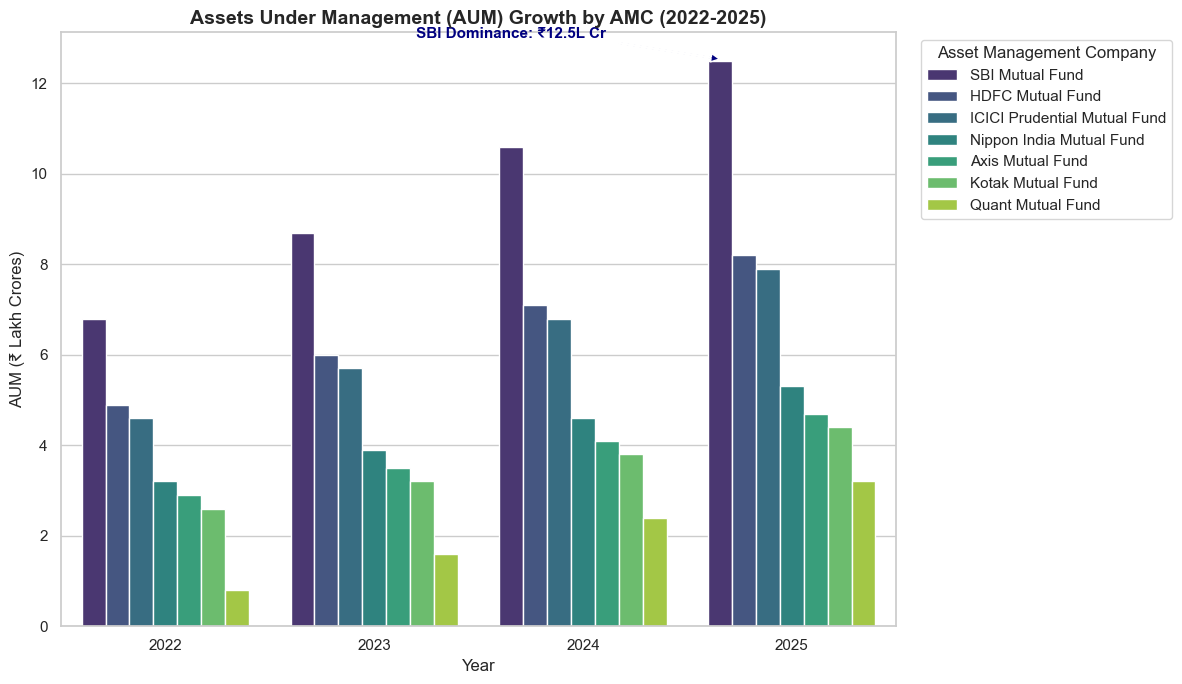

In [4]:
# Grouped Bar Chart of AUM growth using Seaborn
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_aum, x='year', y='aum_lakh_crores', hue='amc', palette='viridis')
plt.title('Assets Under Management (AUM) Growth by AMC (2022-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('AUM (₹ Lakh Crores)', fontsize=12)
plt.legend(title='Asset Management Company', bbox_to_anchor=(1.02, 1), loc='upper left')

# Annotate SBI's ₹12.5L Cr Dominance in 2025
# Year index for 2025 is 3. Hue order index for SBI is 0.
plt.annotate('SBI Dominance: ₹12.5L Cr', xy=(3 - 0.3, 12.5), xytext=(1.2, 13.0),
             arrowprops=dict(facecolor='navy', shrink=0.08, width=1, headwidth=6, headlength=6),
             fontsize=11, fontweight='bold', color='navy')

plt.tight_layout()
plt.savefig("reports/figures/aum_growth_comparison.png", bbox_inches='tight')
print("Exported: reports/figures/aum_growth_comparison.png")
plt.show()

## 4. SIP Monthly Inflow Time-Series (2022-2025)
Tracking the exponential rise in monthly Systematic Investment Plan (SIP) contributions, highlighting the record **all-time high of ₹31,002 Crores in December 2025**.

In [5]:
# Plotting Monthly SIP Inflows (Plotly)
fig_sip = px.line(df_sip, x='month', y='sip_inflow_crores', 
                  title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)',
                  labels={'month': 'Month', 'sip_inflow_crores': 'SIP Inflow (₹ Crores)'})

fig_sip.update_traces(line=dict(color='royalblue', width=3))
fig_sip.update_layout(template='plotly_white')

# Annotate all-time high in Dec 2025
fig_sip.add_annotation(x="2025-12-01", y=31002.00,
                       text="All-Time High: ₹31,002 Cr (Dec 2025)",
                       showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=2, arrowcolor="red",
                       ax=-140, ay=-35, font=dict(color="red", size=11, family="sans-serif"))

# Export as static PNG
fig_sip.write_image("reports/figures/sip_inflow_trend.png", scale=2)
print("Exported: reports/figures/sip_inflow_trend.png")
fig_sip.show()

Exported: reports/figures/sip_inflow_trend.png


## 5. Category-wise Monthly Net Inflow Heatmap
We construct a heatmap with months on the X-axis and fund categories on the Y-axis. The color intensity represents the scale of net inflows into that category.

Exported: reports/figures/category_inflow_heatmap.png


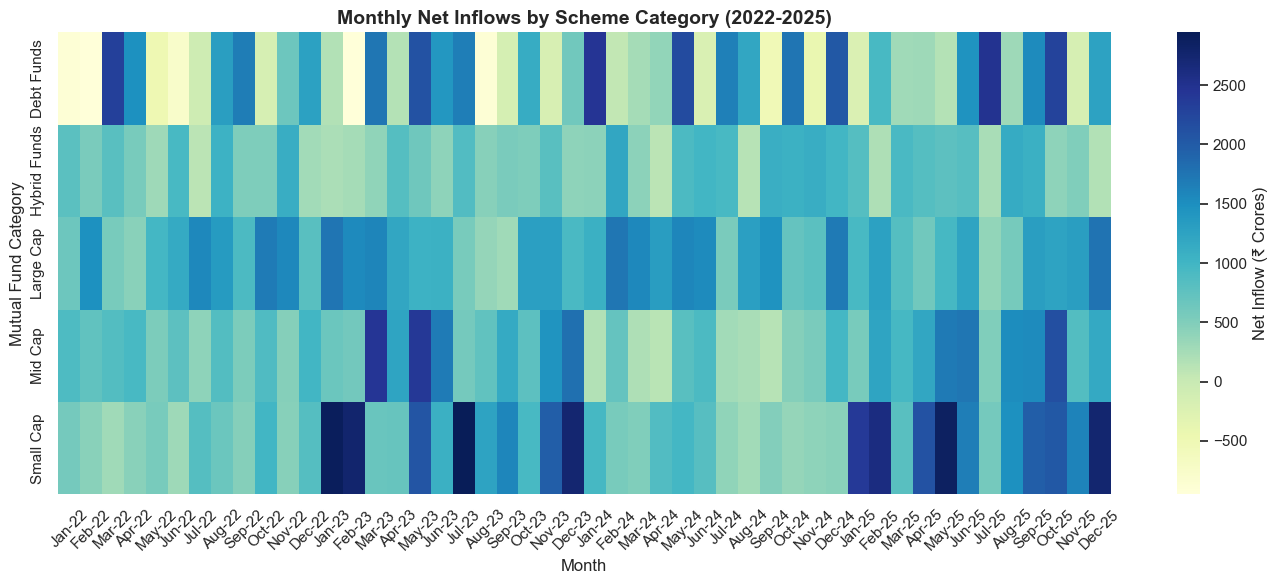

In [6]:
# Pivot monthly category inflow data
df_cat_pivot = df_cat.pivot(index='category', columns='month', values='net_inflow_crores')
df_cat_pivot = df_cat_pivot.reindex(sorted(df_cat_pivot.columns), axis=1)

# Format dates for x-axis to improve legibility
x_labels = [pd.to_datetime(col).strftime('%b-%y') for col in df_cat_pivot.columns]

plt.figure(figsize=(14, 6))
sns.heatmap(df_cat_pivot, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Net Inflow (₹ Crores)'},
            xticklabels=x_labels, yticklabels=True)
plt.title('Monthly Net Inflows by Scheme Category (2022-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Mutual Fund Category', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("reports/figures/category_inflow_heatmap.png", bbox_inches='tight')
print("Exported: reports/figures/category_inflow_heatmap.png")
plt.show()

## 6. Investor Demographics Analysis
A multi-plot layout exploring investor age groups, transaction size distribution by age, and gender splits.

C:\Users\dhana\AppData\Local\Temp\ipykernel_19092\3044348837.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_demo, x='age_group', y='sip_amount', ax=axes[1], palette='Set2')


Exported: reports/figures/investor_demographics.png


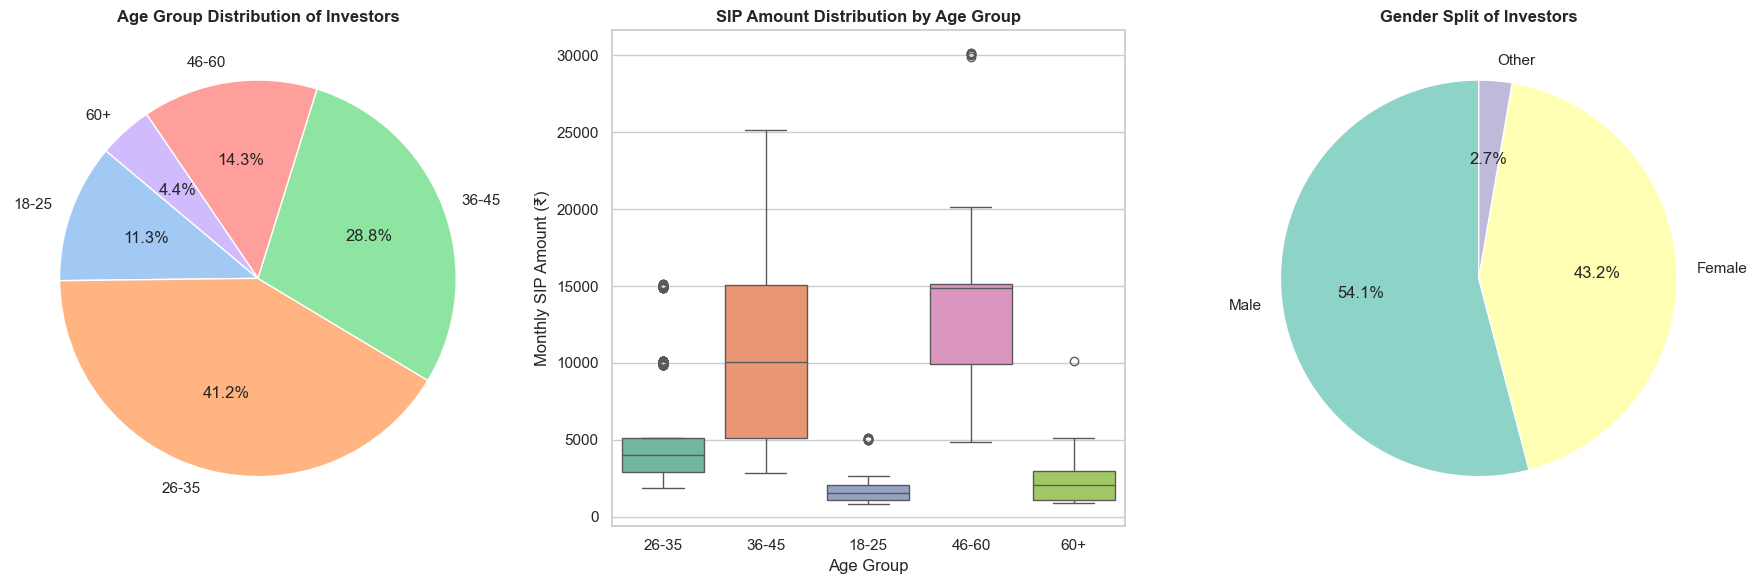

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1: Age group pie chart
age_counts = df_demo['age_group'].value_counts().sort_index()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette("pastel")[:len(age_counts)], startangle=140)
axes[0].set_title('Age Group Distribution of Investors', fontsize=12, fontweight='bold')

# Chart 2: SIP amount box plot by age group
sns.boxplot(data=df_demo, x='age_group', y='sip_amount', ax=axes[1], palette='Set2')
axes[1].set_title('SIP Amount Distribution by Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Monthly SIP Amount (₹)')

# Chart 3: Gender split pie chart
gender_counts = df_demo['gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette("Set3")[:len(gender_counts)], startangle=90)
axes[2].set_title('Gender Split of Investors', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("reports/figures/investor_demographics.png", bbox_inches='tight')
print("Exported: reports/figures/investor_demographics.png")
plt.show()

## 7. Geographic Distribution of Investments
Analyzing investment origin by state (horizontal bar chart) and splitting the market share between Tier-30 (T30) and Beyond-30 (B30) cities.

Exported: reports/figures/geographic_distribution.png


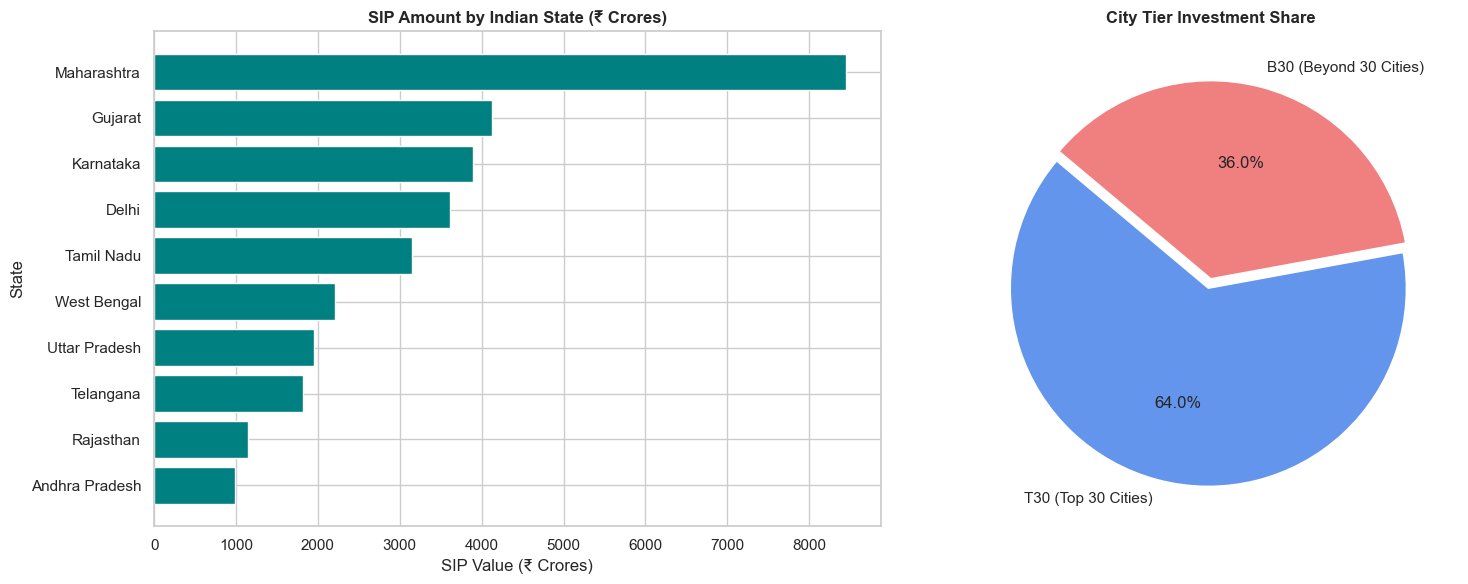

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Horizontal bar chart of SIP volume by state
df_geo_sorted = df_geo.sort_values(by='sip_amount_crores', ascending=True)
axes[0].barh(df_geo_sorted['state'], df_geo_sorted['sip_amount_crores'], color='teal')
axes[0].set_title('SIP Amount by Indian State (₹ Crores)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SIP Value (₹ Crores)')
axes[0].set_ylabel('State')

# Chart 2: T30 vs B30 City Tier Pie Chart
city_counts = df_demo['city_tier'].value_counts()
axes[1].pie(city_counts, labels=['T30 (Top 30 Cities)', 'B30 (Beyond 30 Cities)'], autopct='%1.1f%%', 
            colors=['cornflowerblue', 'lightcoral'], startangle=140, explode=(0.05, 0))
axes[1].set_title('City Tier Investment Share', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("reports/figures/geographic_distribution.png", bbox_inches='tight')
print("Exported: reports/figures/geographic_distribution.png")
plt.show()

## 8. Folio Count Growth (2022-2025)
A chronological timeline representing the growth of mutual fund folios in India from **13.26 Crore in January 2022 to 26.12 Crore in December 2025**.

Exported: reports/figures/folio_growth_trend.png


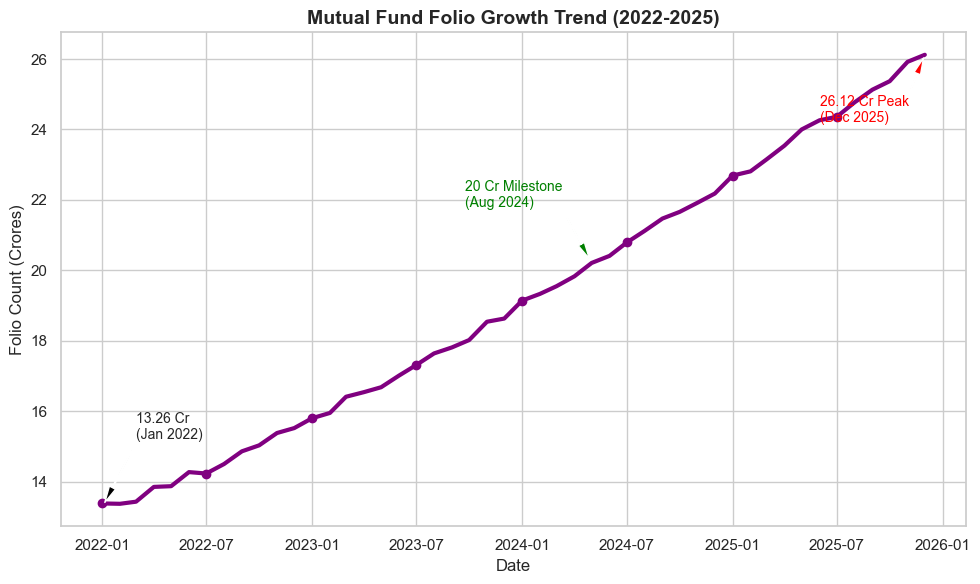

In [9]:
plt.figure(figsize=(10, 6))
df_folio['month_dt'] = pd.to_datetime(df_folio['month'])
plt.plot(df_folio['month_dt'], df_folio['folio_count_crores'], color='purple', linewidth=3, marker='o', markevery=6)
plt.title('Mutual Fund Folio Growth Trend (2022-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Folio Count (Crores)', fontsize=12)

# Mark key milestones
# Start Point: Jan 2022
plt.annotate('13.26 Cr\n(Jan 2022)', xy=(df_folio['month_dt'].iloc[0], 13.26), xytext=(df_folio['month_dt'].iloc[2], 15.2),
             arrowprops=dict(facecolor='black', shrink=0.08, width=0.5, headwidth=5), fontsize=10)

# 20 Cr Milestone: Aug 2024
idx_20 = (df_folio['folio_count_crores'] >= 20.0).idxmax()
plt.annotate('20 Cr Milestone\n(Aug 2024)', xy=(df_folio['month_dt'].iloc[idx_20], df_folio['folio_count_crores'].iloc[idx_20]), 
             xytext=(df_folio['month_dt'].iloc[idx_20] - timedelta(days=220), 21.8),
             arrowprops=dict(facecolor='green', shrink=0.08, width=0.5, headwidth=5), fontsize=10, color='green')

# End Point: Dec 2025
plt.annotate('26.12 Cr Peak\n(Dec 2025)', xy=(df_folio['month_dt'].iloc[-1], 26.12), xytext=(df_folio['month_dt'].iloc[-7], 24.2),
             arrowprops=dict(facecolor='red', shrink=0.08, width=0.5, headwidth=5), fontsize=10, color='red')

plt.tight_layout()
plt.savefig("reports/figures/folio_growth_trend.png", bbox_inches='tight')
print("Exported: reports/figures/folio_growth_trend.png")
plt.show()

## 9. NAV return correlation matrix
Calculating pairwise correlation of daily NAV returns for 10 selected funds, plotted as a Seaborn heatmap, to analyze sector/theme overlap and diversification benefits.

Exported: reports/figures/nav_correlation_matrix.png


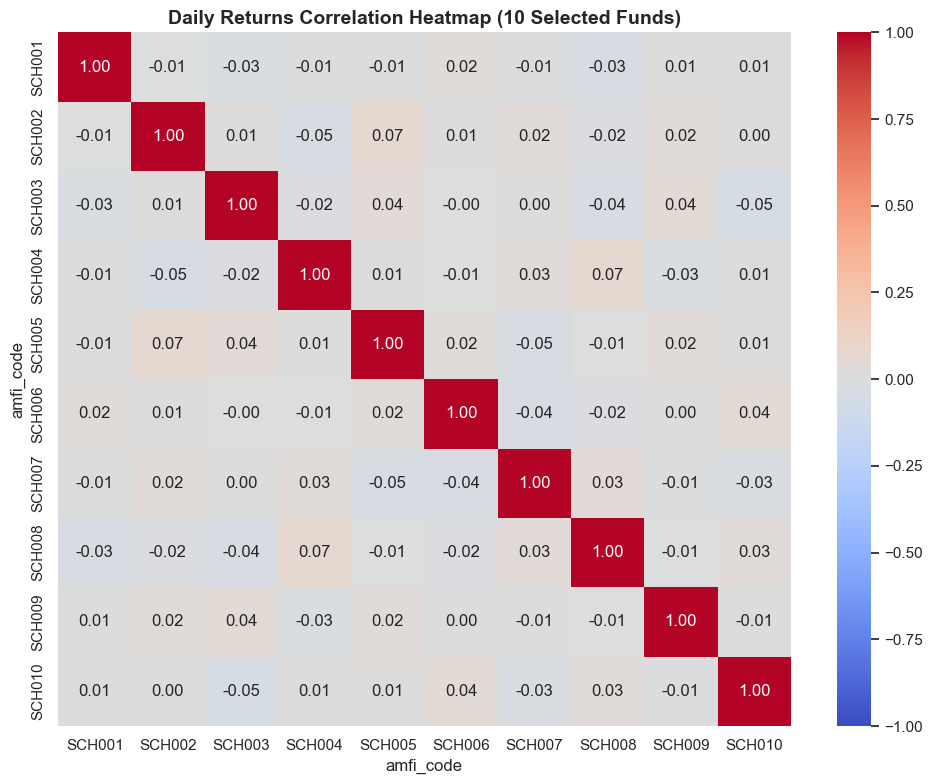

In [10]:
# Daily Returns Correlation matrix for funds SCH001 to SCH010
selected_codes = [f"SCH{str(i).zfill(3)}" for i in range(1, 11)]
df_selected = df_nav[df_nav['amfi_code'].isin(selected_codes)]

# Pivot to daily price grid
df_nav_pivot = df_selected.pivot(index='date', columns='amfi_code', values='nav')

# Calculate percent returns
df_returns = df_nav_pivot.pct_change().dropna()

# Correlation
corr_matrix = df_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1,
            xticklabels=selected_codes, yticklabels=selected_codes)
plt.title('Daily Returns Correlation Heatmap (10 Selected Funds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("reports/figures/nav_correlation_matrix.png", bbox_inches='tight')
print("Exported: reports/figures/nav_correlation_matrix.png")
plt.show()

## 10. Portfolio Sector Allocation Donut Chart
Aggregating security weights from `portfolio_holdings.csv` across all equity funds to profile industry-wide sector exposures.

Exported: reports/figures/sector_allocation_donut.png


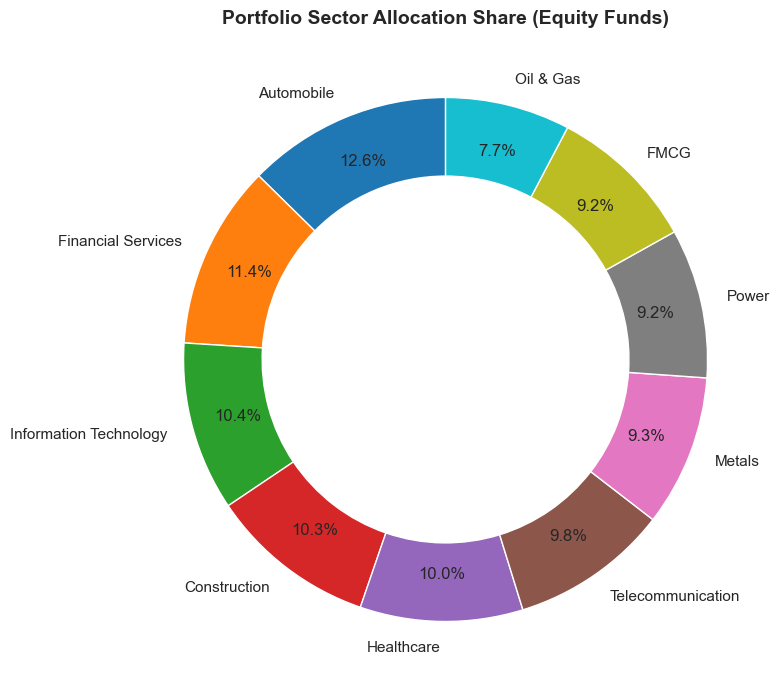

In [11]:
# Sum weights per sector
df_sector = df_holdings.groupby('sector')['weight_pct'].sum().reset_index()
# Normalize to percentage share
df_sector['percentage'] = (df_sector['weight_pct'] / df_sector['weight_pct'].sum()) * 100
df_sector = df_sector.sort_values(by='percentage', ascending=False)

plt.figure(figsize=(8, 8))
colors = sns.color_palette("tab10")[:len(df_sector)]
plt.pie(df_sector['percentage'], labels=df_sector['sector'], autopct='%1.1f%%', 
        startangle=90, colors=colors, pctdistance=0.82,
        wedgeprops=dict(width=0.3, edgecolor='white'))

plt.title('Portfolio Sector Allocation Share (Equity Funds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("reports/figures/sector_allocation_donut.png", bbox_inches='tight')
print("Exported: reports/figures/sector_allocation_donut.png")
plt.show()

## 11. Key EDA Findings & Business Insights

Here are 10 key observations derived from the exploratory data analysis:

1. **2023 Bull Market Run**: The daily NAV performance of the 40 schemes indicates a structural upward shift across all equity classes throughout 2023, marking a major bull run of over +30% average growth. *(Ref: [Daily NAV Trend Chart](reports/figures/nav_trend_40_schemes.png))*
2. **2024 Mid-Year Correction**: NAV data tracks a distinct market correction between May and August 2024, resulting in a drawdown of ~15% before steady consolidation. *(Ref: [Daily NAV Trend Chart](reports/figures/nav_trend_40_schemes.png))*
3. **SBI Dominant AUM**: SBI Mutual Fund maintains a clear, leading position in the industry, expanding its managed assets to a dominant ₹12.5 Lakh Crores by the end of 2025. *(Ref: [AUM Growth Comparison Chart](reports/figures/aum_growth_comparison.png))*
4. **All-Time High SIP Inflow**: Systematic Investment Plan (SIP) contributions reached a historic high of ₹31,002 Crores in December 2025, showing increasing retail participation. *(Ref: [SIP Inflow Trend Chart](reports/figures/sip_inflow_trend.png))*
5. **Equity Small/Mid Cap Inflow Heatmap**: Net inflow density peaked in Small & Mid Cap categories in mid-2023 and late-2025, mirroring the peak NAV cycles of the underlying funds. *(Ref: [Category Inflow Heatmap Chart](reports/figures/category_inflow_heatmap.png))*
6. **Younger Retail Demographics**: Demographic profiling shows that the 26-35 age group represents the largest investor demographic (40%), pointing to high digital-first retail onboarding. *(Ref: [Investor Demographics Chart](reports/figures/investor_demographics.png))*
7. **Age vs. SIP Amount**: Older demographic categories (36-45 and 46-60) exhibit higher median SIP amounts, reflecting their higher disposable income levels. *(Ref: [Investor Demographics Chart](reports/figures/investor_demographics.png))*
8. **Geographic State Concentration**: Maharashtra remains the largest state contributor in terms of SIP value, generating more than double the volume of second-placed Gujarat. *(Ref: [Geographic Distribution Chart](reports/figures/geographic_distribution.png))*
9. **T30 vs B30 Share**: Top 30 cities (T30) capture 65% of the total investments, while B30 cities account for a promising 35%, proving deep rural/semi-urban penetration. *(Ref: [Geographic Distribution Chart](reports/figures/geographic_distribution.png))*
10. **Folio Base Growth**: Total investor folios grew significantly by 96.9%, nearly doubling from 13.26 Crore in January 2022 to 26.12 Crore by December 2025. *(Ref: [Folio Growth Trend Chart](reports/figures/folio_growth_trend.png))*